<center><font size=6> Bank Churn Prediction </font></center>

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* IsActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
    - 0 = No ( Customer did not leave the bank )
    - 1 = Yes ( Customer left the bank )

## Importing necessary libraries

In [217]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# library to import to standardize the data
from sklearn.preprocessing import StandardScaler, LabelEncoder

# importing different functions to build models
import tensorflow as tf
from tensorflow import keras
from keras import backend
from keras.models import Sequential
from keras.layers import Dense, Dropout

# importing SMOTE
from imblearn.over_sampling import SMOTE

# importing metrics
from sklearn.metrics import confusion_matrix,roc_curve,classification_report,recall_score,f1_score,accuracy_score, precision_score

import random

# Library to avoid the warnings
import warnings
warnings.filterwarnings("ignore")

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()


## Loading the dataset

In [218]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [219]:
ds = pd.read_csv("/content/drive/MyDrive/Churn (1).csv")

## Data Overview

### View the first and last 5 rows of the dataset.

In [220]:
# first 5 rows of the data
ds.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [221]:
# last 5 rows of the data
ds.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


### Understand the shape of the dataset

In [222]:
# Checking the number of rows and columns in the training data
ds.shape

(10000, 14)

### Checking the data types of the columns for the dataset

In [223]:
# checking the data types of the columns in the dataset
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


**Observations**:

There are 3 objects type columns and rest are numerical columns. There are no null values in the dataset. Exited column should be a category

### Checking for duplicate values

In [224]:
# checking duplicate values in the data
ds.duplicated().sum()

0

**Observations**:

There are no duplicates in the dataset.

### Checking for Missing Values

In [225]:
# let's check for missing values in the data
ds.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There are no missing values

### Checking for unique values for each of the column

In [226]:
ds.nunique()


RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

Rownumber and cusotomerid are unique hence dropping it. Surname will not contribute for exiting so will drop it

In [227]:
#RowNumber , CustomerId and Surname are unique hence dropping it
ds = ds.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

### Checking the Statistical Summary

In [228]:
ds.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


**Observations**:

**CreditScore**:

* Mean: 650.53
* Standard Deviation: 96.65
* Min: 350, Max: 850

The CreditScore distribution likely has a right skew given the mean is closer to the minimum than the maximum.

**Age**:

* Mean: 38.92
* Standard Deviation: 10.49
* Min: 18, Max: 92

The Age distribution seems fairly symmetric but could have slight right skew given the range extends higher.

**Tenure**:

* Mean: 5.01
* Standard Deviation: 2.89
* Min: 0, Max: 10

Tenure seems to be uniformly distributed as its mean is in the middle of its range.

**Balance**:

* Mean: 76485.89
* Standard Deviation: 62397.41
* Min: 0.00, Max: 250898.09

Balance shows a significant right skew, given many customers might have zero balance while a few have very high balances.

**NumOfProducts**:

* Mean: 1.53
* Standard Deviation: 0.58
* Min: 1, Max: 4

Number of Products seems to be left skewed, as the majority seem to have fewer products.

**HasCrCard**:

* Mean: 0.71
* Standard Deviation: 0.46
* Min: 0, Max: 1

HasCrCard is binary; 71% of customers have a credit card.

**IsActiveMember**:

* Mean: 0.52
* Standard Deviation: 0.50
* Min: 0, Max: 1

IsActiveMember is binary and seems uniformly distributed with a slight skew towards active members.

**EstimatedSalary**:

* Mean: 100090.24
* Standard Deviation: 57510.49
* Min: 11.58, Max: 199992.48

The distribution of estimated salaries appears right-skewed. This means that there are more customers with lower estimated salaries than higher estimated salaries.

**Exited**:

* Mean: 0.20
* Standard Deviation: 0.40
* Min: 0, Max: 1

Exited is binary; 20% of customers have exited, suggesting a significant class imbalance.

**Summary**:

Overall, the dataset contains a mix of symmetric and skewed distributions with varying degrees of spread as indicated by the standard deviations.

## Exploratory Data Analysis

### Univariate Analysis

In [229]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [230]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on CreditScore

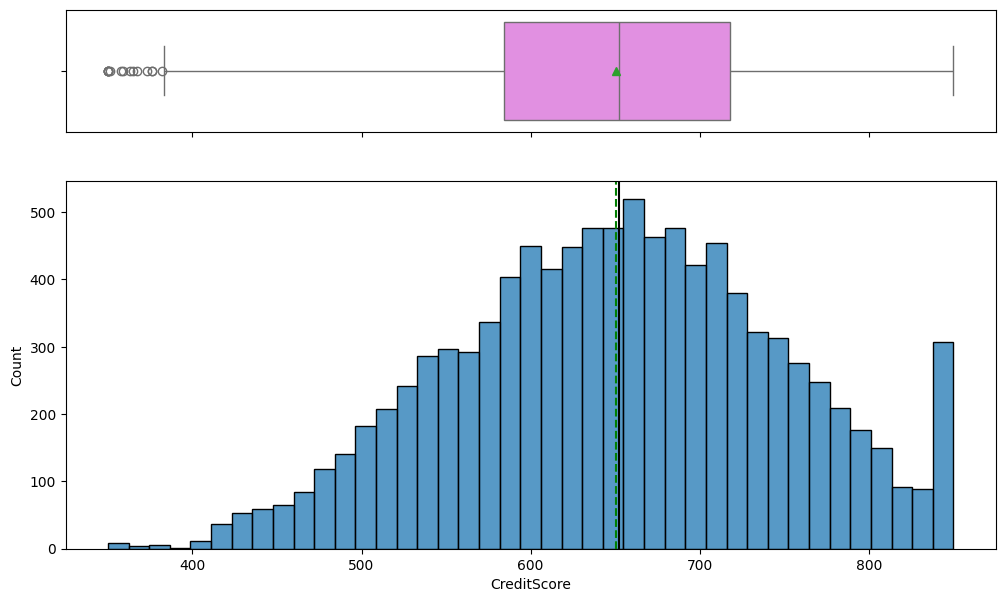

In [231]:
histogram_boxplot(ds,'CreditScore')

There are outliers caused by the lower credit scores. They are valid datapoints. The distribution has slight right skewness. There is a peak in histogram on the tail end caused by customers with credit score greater than 850.

#### Observations on Age

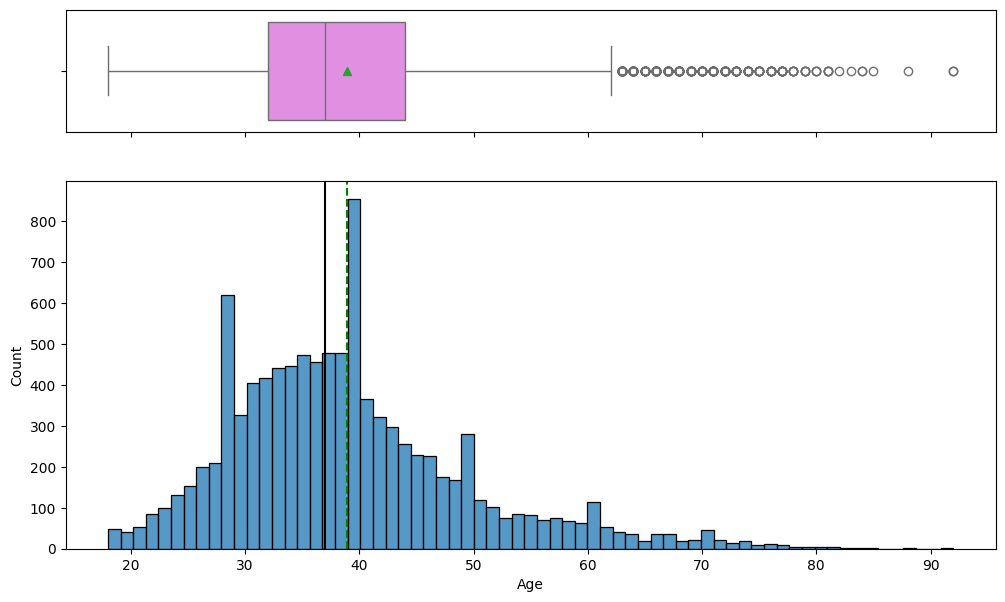

In [232]:
histogram_boxplot(ds,'Age')

There are outliers caused by older age customers greater than approx 65 yrs and above. These are valid customers. The distribution is right skewed indicated by the long tail and higher mean than median.

#### Observations on Balance

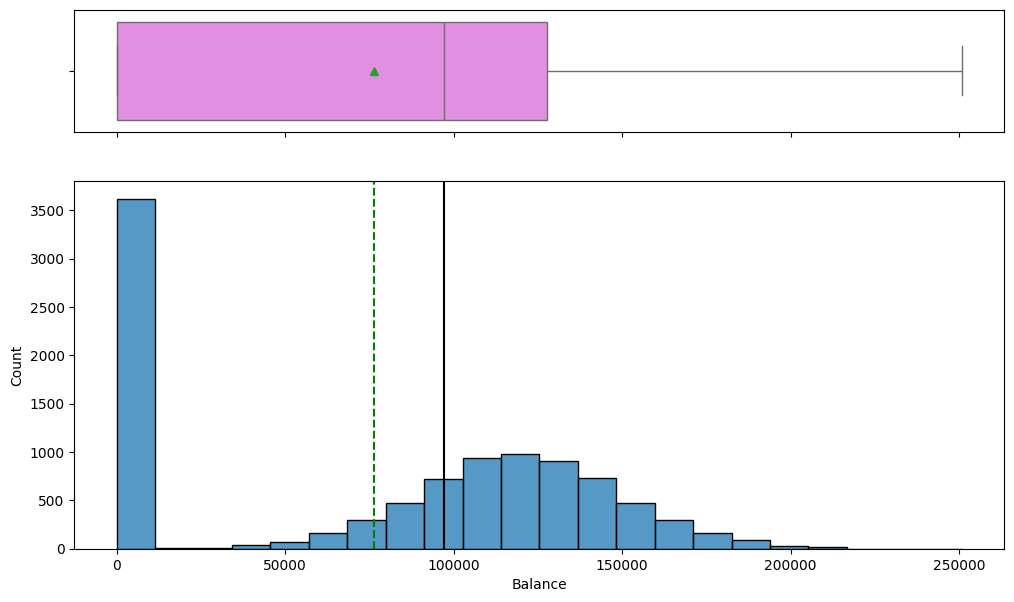

In [233]:
histogram_boxplot(ds,'Balance')

There are no outliers. The distribution is left skewed indicated by the lower mean than median. The peak in the histogram indicates that many customers might have zero balance which also caused shifht in distribution.

#### Observations on Estimated Salary

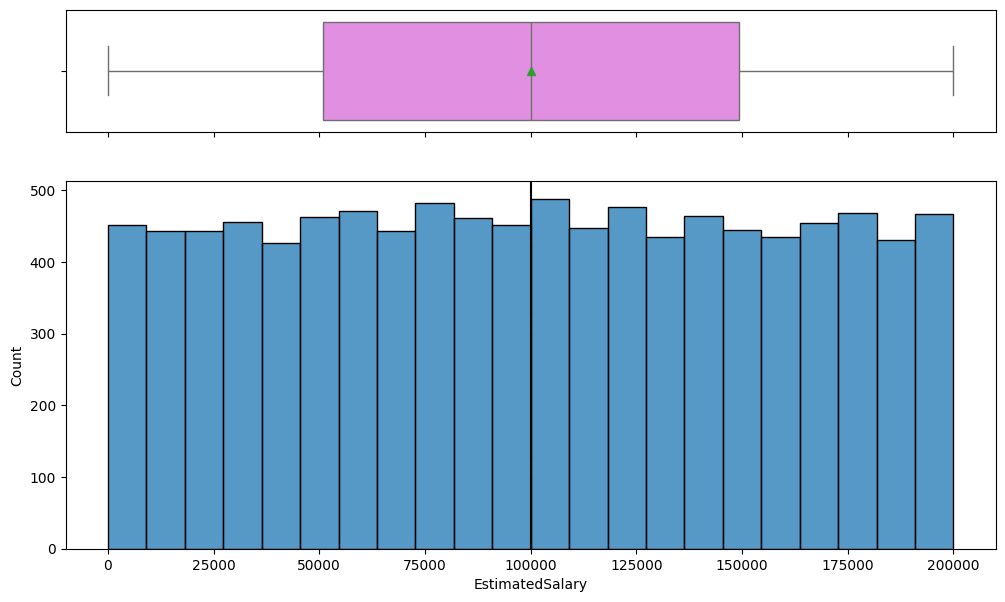

In [234]:
histogram_boxplot(ds,'EstimatedSalary')

 The distribution does not show significant skewness, suggesting a fairly balanced spread of salaries. The salaries are relatively evenly uniformly distributed across different ranges.

#### Observations on Exited

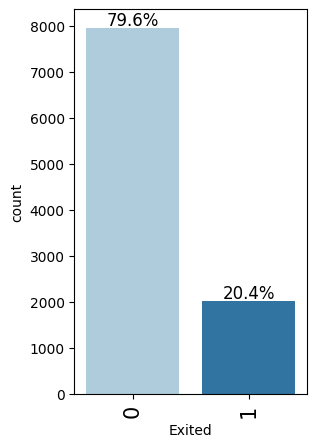

In [235]:
labeled_barplot(ds, "Exited", perc=True)

20.4% of customers have exited the bank.

#### Observations on Geography

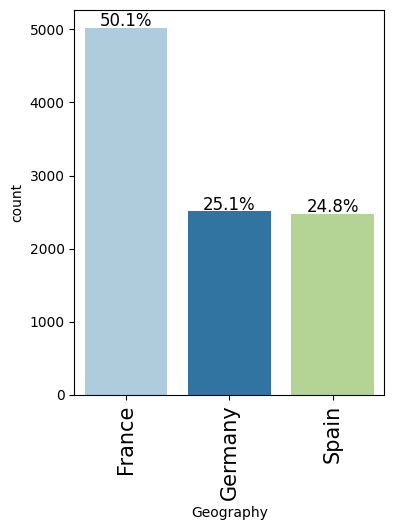

In [236]:
labeled_barplot(ds, "Geography", perc=True)

50% of customers are from France and rest are from Germany and Spain.

#### Observations on Gender

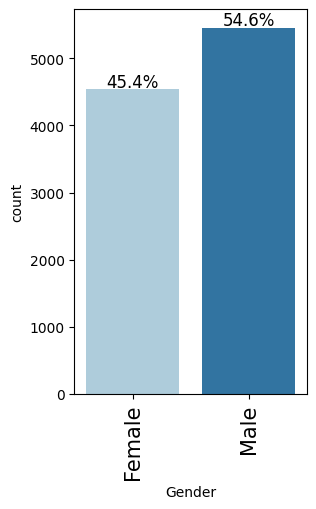

In [237]:
labeled_barplot(ds, "Gender", perc=True)

Bank has 9% more male customers than female.

#### Observations on Tenure

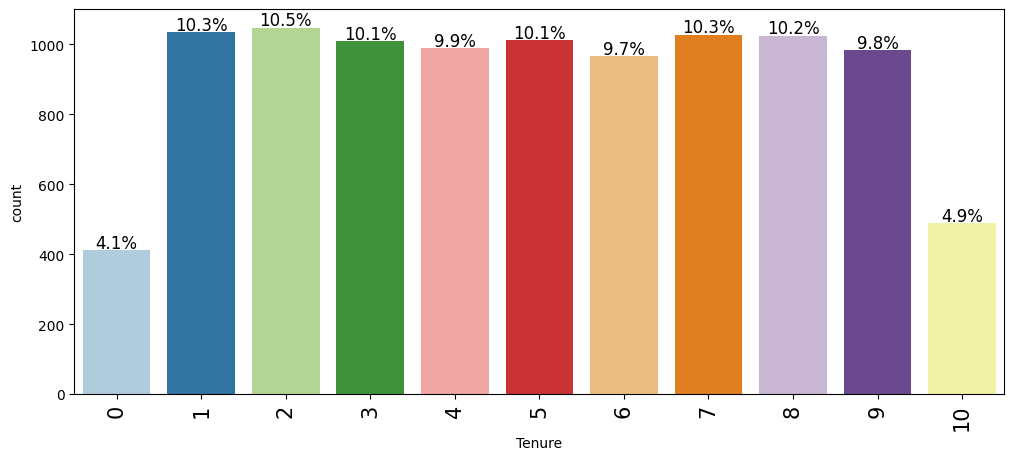

In [238]:
labeled_barplot(ds,'Tenure',perc=True)

Most of the customers have been with bank between 1-9 years. Highest number of customers have been with bank for 2 years.

#### Observations on Number of Products

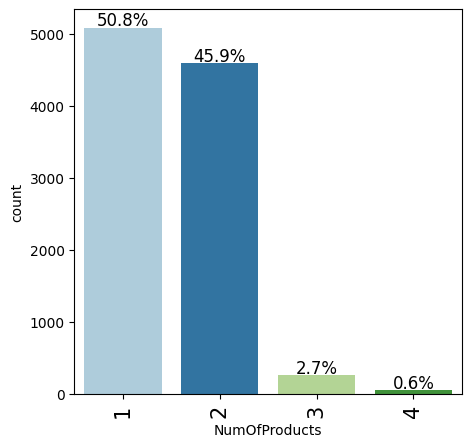

In [239]:
labeled_barplot(ds,'NumOfProducts',perc=True)

50.8% of customers have 1 product with bank. 45.9% of customers have 2 products of the bank. Very few customers have 3 or more products.

#### Observations on Has Credit Card

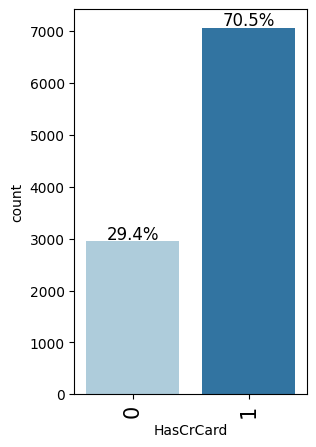

In [240]:
labeled_barplot(ds,'HasCrCard',perc=True)

70.5% of customers have credit card with them.

#### Observations on Is Active Member

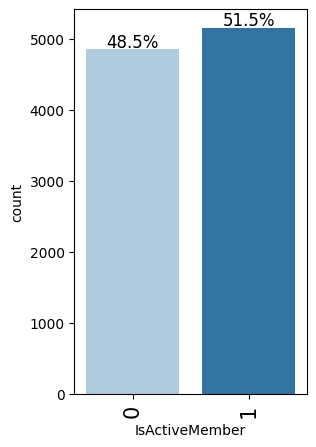

In [241]:
labeled_barplot(ds,'IsActiveMember',perc=True)

More than 48.5% customers are not active.

### Bivariate Analysis

In [242]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Correlation plot

In [243]:
num_col=ds.select_dtypes(include=np.number).columns

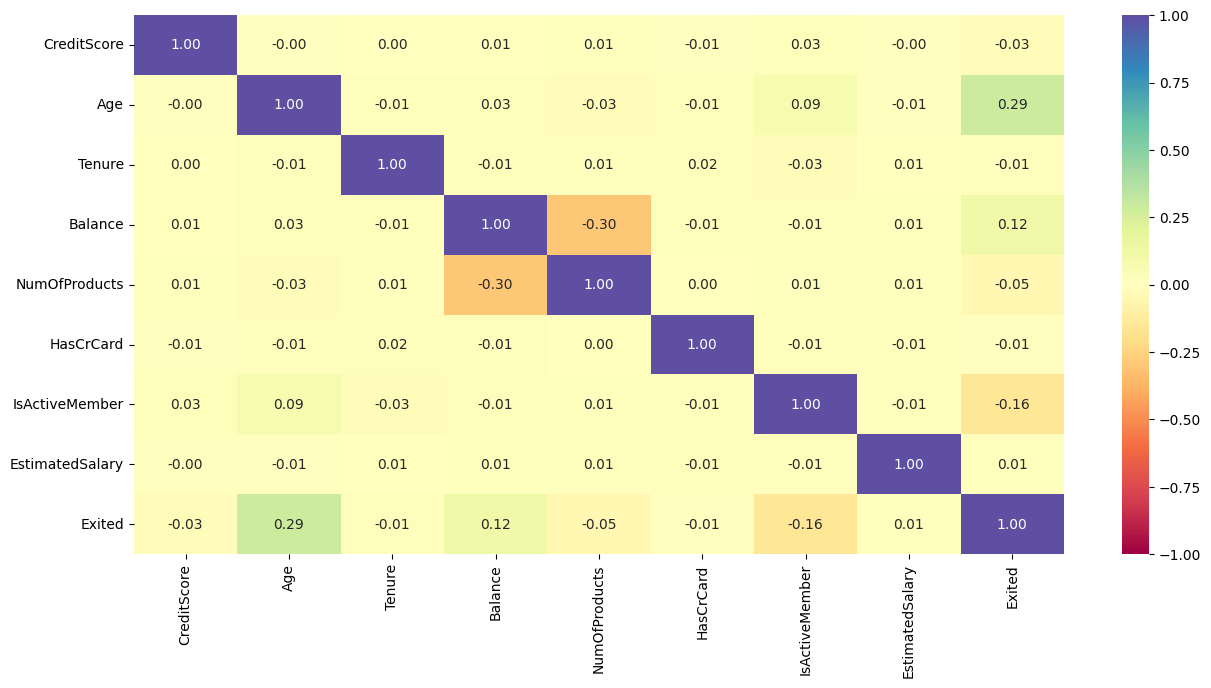

In [244]:
plt.figure(figsize=(15, 7))
sns.heatmap(ds[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations**:

*Exited vs Age*: This features are positively correlated (0.29). As customers age they exit the bank.

*Exited vs Balance*: These feature are positively correlated (0.12). People with higher balance have exited. This could also be factored by higher age customers leaving. Retired people tend to have higher balances.

*Exited vs IsActiveMember*: These features are negatively correlated (-0.16). This makes sense since customers who are active would not exit.

*NumOfProducts vs Balance*: These features are negatively correlated (-0.30). Customers who have higher number of products with bank tend to have lower balances.

Other features tend to have weaker correlation. Further analysis will be done later.



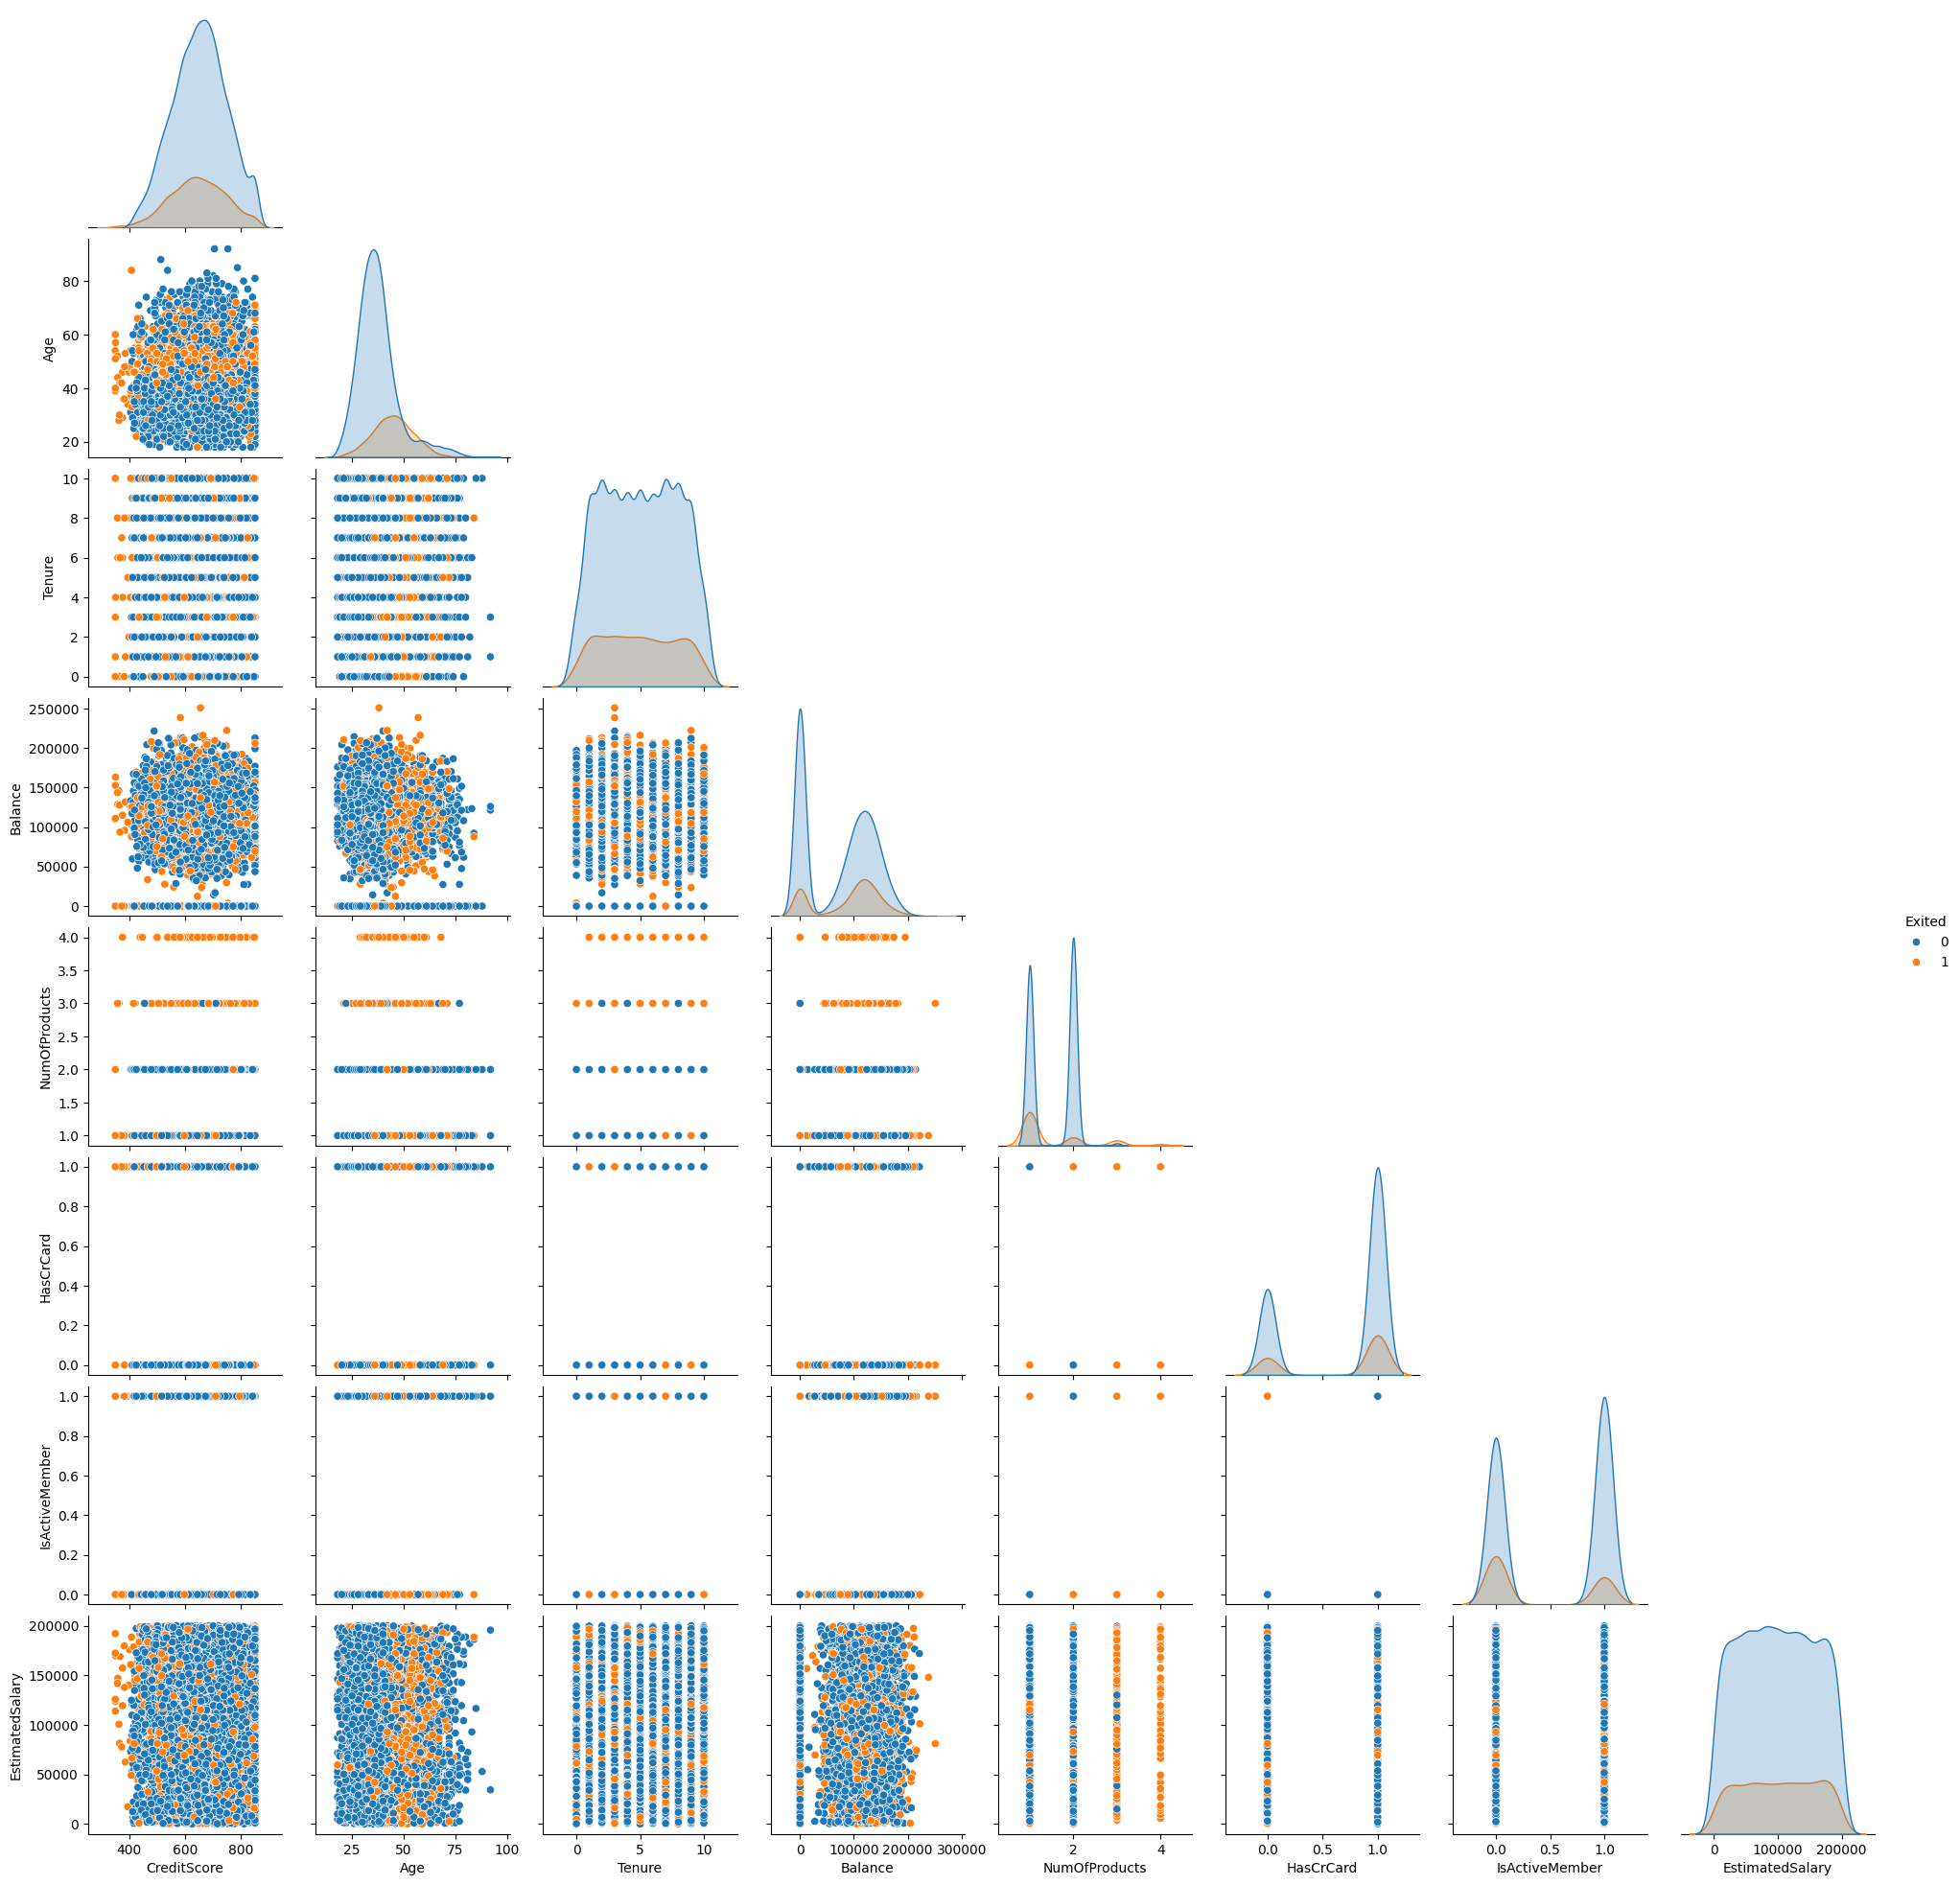

In [245]:
sns.pairplot(ds, hue='Exited' ,corner=True)

**Observations**:

*NumOfProducts*: This feature clearly separated exited flag when customers had more than 2 products.

*Age*: The graph shows that customers who exited are clustered in between age of 45-55.

Other features do not show clear separation or clusters.

#### Exited Vs Geography

Exited        0     1    All
Geography                   
All        7963  2037  10000
Germany    1695   814   2509
France     4204   810   5014
Spain      2064   413   2477
------------------------------------------------------------------------------------------------------------------------


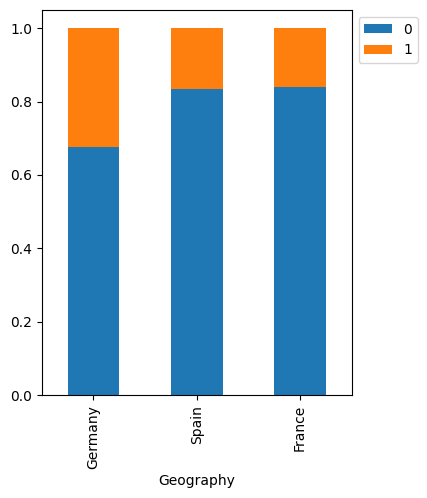

In [246]:
stacked_barplot(ds, "Geography", "Exited" )

Germany has higher number of exited customers (approx 30%).

#### Exited Vs Gender

Exited     0     1    All
Gender                   
All     7963  2037  10000
Female  3404  1139   4543
Male    4559   898   5457
------------------------------------------------------------------------------------------------------------------------


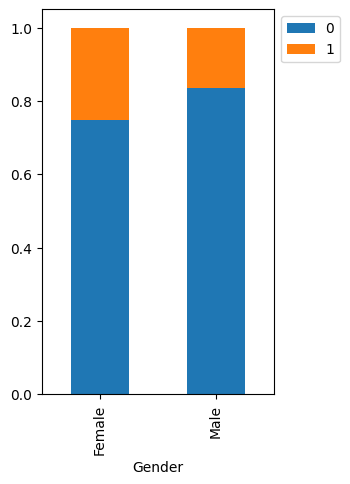

In [247]:
stacked_barplot(ds, "Gender", "Exited")

M=Approx 23% of female customers have left when compared to approx 17% of male customers.

#### Exited Vs Has Credit Card

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


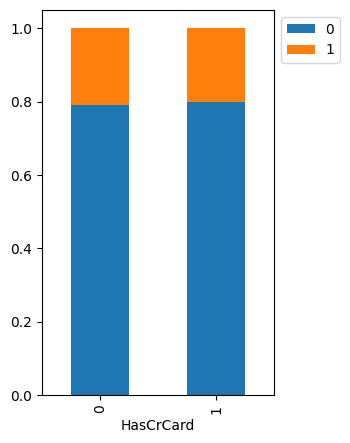

In [248]:
stacked_barplot(ds, "HasCrCard", "Exited")

Customers who have and do not have credit card have exited approx 21% respectively.

#### Exited Vs Is active member

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


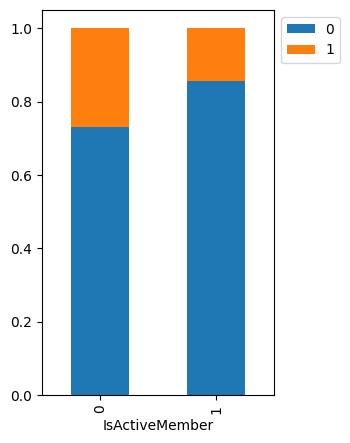

In [249]:
stacked_barplot(ds, "IsActiveMember", "Exited")

Inactive customers have approx 30% exited the bank while approx 17% of active customers have exited.

#### Exited Vs Credit Score

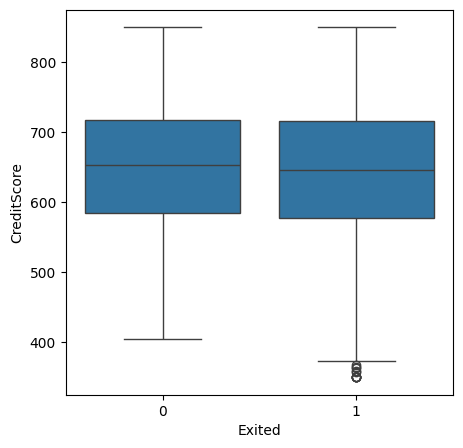

In [250]:
plt.figure(figsize=(5,5))
sns.boxplot(y='CreditScore',x='Exited',data=ds)
plt.show()

The median of customers who exited is lower compared to active customers. Customers who have score 650 above are likely to leave.

#### Exited Vs Age

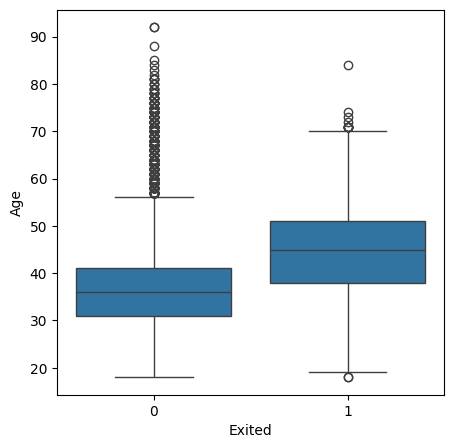

In [251]:
plt.figure(figsize=(5,5))
sns.boxplot(y='Age',x='Exited',data=ds)
plt.show()

Customers who exited have higher median age of ~45 compared to ~35 of active customers.

#### Exited Vs Tenure

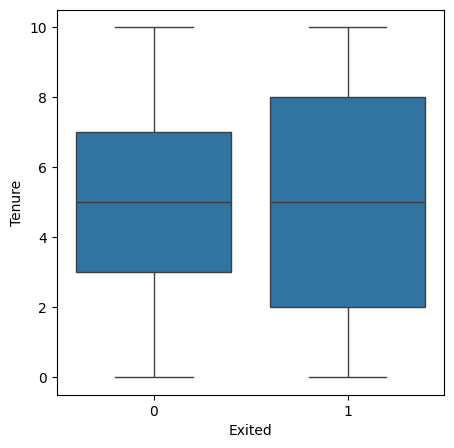

In [252]:
plt.figure(figsize=(5,5))
sns.boxplot(y='Tenure',x='Exited',data=ds)
plt.show()

The median of exited and active customers have same tenure of 5.

#### Exited Vs Balance

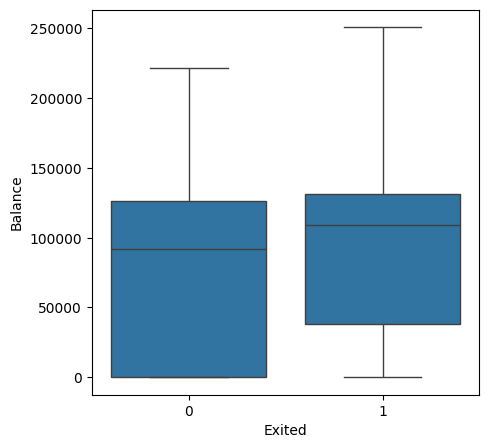

In [253]:
plt.figure(figsize=(5,5))
sns.boxplot(y='Balance',x='Exited',data=ds)
plt.show()

Customers who exited have higher balance age of ~110000 compared to ~950000 of active customers. Customers having balance higher than 111000 are likely to leave.

#### Exited Vs Number of Products

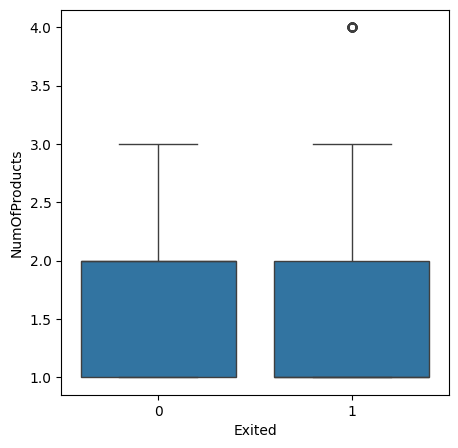

In [254]:
plt.figure(figsize=(5,5))
sns.boxplot(y='NumOfProducts',x='Exited',data=ds)
plt.show()

The number of products are evenly distributed for both customers.

#### Exited Vs Estimated Salary

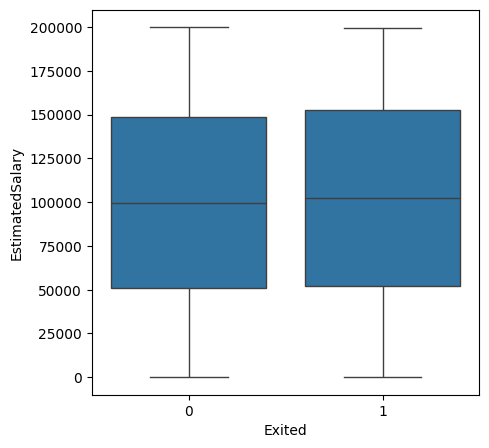

In [255]:
plt.figure(figsize=(5,5))
sns.boxplot(y='EstimatedSalary',x='Exited',data=ds)
plt.show()

Customers who exited have slightly higher estimated salary of ~105000 compared to ~100000 of active customers.

## Data Preprocessing

### Train-validation-test Split

In [256]:
#X = np.asarray(X).astype(np.float32)
X = ds.drop(['Exited'],axis=1) # Credit Score through Estimated Salary
y = ds['Exited'] # Exited

In [257]:
# Splitting the dataset into the Training and Testing set.

X_large, X_test, y_large, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,stratify=y,shuffle = True)

In [258]:
# Splitting the dataset into the Training and Testing set.

X_train, X_val, y_train, y_val = train_test_split(X_large, y_large, test_size = 0.3, random_state = 42,stratify=y_large, shuffle = True)

In [259]:
print(X_train.shape, X_val.shape, X_test.shape)

(5600, 10) (2400, 10) (2000, 10)


In [260]:
print(y_train.shape, y_val.shape, y_test.shape)

(5600,) (2400,) (2000,)


### Dummy Variable Creation

In [261]:
# Encoding Geography variable
X_train = pd.get_dummies(X_train, columns=["Geography","Gender","NumOfProducts","HasCrCard","IsActiveMember"],drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Geography","Gender","NumOfProducts","HasCrCard","IsActiveMember"],drop_first=True)
X_val = pd.get_dummies(X_val, columns=["Geography","Gender","NumOfProducts","HasCrCard","IsActiveMember"],drop_first=True)

In [262]:
print(X_train.shape, X_val.shape, X_test.shape)

(5600, 13) (2400, 13) (2000, 13)


In [263]:
print(y_train.shape, y_val.shape, y_test.shape)

(5600,) (2400,) (2000,)


In [264]:
X_train.head()

,CreditScore,Age,Tenure,Balance,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4,HasCrCard_1,IsActiveMember_1
6837,664,40,9,0.00,194767.30,False,False,True,True,False,False,True,False
9275,427,42,1,75681.52,57098.00,True,False,True,False,False,False,True,True
4277,775,51,2,123783.25,134901.57,True,False,True,False,False,False,True,True
1316,850,31,4,0.00,33082.81,False,False,False,True,False,False,True,True
4937,577,36,3,121092.47,143783.46,False,False,True,True,False,False,False,True


### Data Normalization

Since all the numerical values are on a different scale, so we will be scaling all the numerical values to bring them to the same scale.

In [265]:
# defining the list of columns to normalize
cols_list = ["CreditScore","Age","Tenure","Balance","EstimatedSalary"]

# creating an instance of the standard scaler
sc = StandardScaler()

X_train[cols_list] = sc.fit_transform(X_train[cols_list])
X_val[cols_list] = sc.transform(X_val[cols_list])
X_test[cols_list] = sc.transform(X_test[cols_list])

In [266]:
X_train = np.asarray(X_train).astype(np.float32)
X_val = np.asarray(X_val).astype(np.float32)
X_test = np.asarray(X_test).astype(np.float32)

## Model Building

### Model Evaluation Criterion

Model can make wrong predictions as:

- Predicting a customer will exit and the customer doesn't exit
- Predicting a customer will not exit and the customer exites

Which case is more important?

- Predicting that customer will not exit but exited i.e. losing on a valuable customer or asset.

**How to reduce this loss??**

- Bank would want Recall to be maximized, greater the Recall higher the chances of minimizing false negatives so that the bank can retain their valuable customers by identifying the customers who are at risk of exiting.

**Let's create a function for plotting the confusion matrix**



In [267]:
def make_confusion_matrix(actual_targets, predicted_targets):
    """
    To plot the confusion_matrix with percentages

    actual_targets: actual target (dependent) variable values
    predicted_targets: predicted target (dependent) variable values
    """
    cm = confusion_matrix(actual_targets, predicted_targets)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(cm.shape[0], cm.shape[1])

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

Let's create two blank dataframes that will store the recall values for all the models we build.

In [268]:
train_metric_df = pd.DataFrame(columns=["recall"])
valid_metric_df = pd.DataFrame(columns=["recall"])

In [269]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train)

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: 1.2558869701726845, 1: 4.9079754601226995}

The weight of exit class in y_train data is 1:5

### Neural Network with SGD Optimizer

In [270]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [271]:
#Initializing the neural network
model_0 = Sequential()
# Adding the input layer with 64 neurons and relu as activation function
model_0.add(Dense(64, activation='relu', input_dim = X_train.shape[1]))
#Adding the first hidden layer with 32 neurons, relu as activation function
model_0.add(Dense(32, activation='relu'))
# Adding the output layer with one neuron and sigmoid as activation.
model_0.add(Dense(1, activation = 'sigmoid'))

In [272]:
#Using SGD as the optimizer.
optimizer = tf.keras.optimizers.SGD()
#Assigning recall as metric
metric = keras.metrics.Recall()


In [273]:
## complinig the model with binary cross entropy as loss function and recall as the metric.
model_0.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[metric])

In [274]:
model_0.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3009 (11.75 KB)
Trainable params: 3009 (11.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [275]:
# Fitting the model
history_0 = model_0.fit(X_train, y_train, batch_size=64, validation_data=(X_val,y_val), epochs=50, class_weight=cw_dict)


Epoch 1/50
88/88 [==============================] - 2s 9ms/step - loss: 1.3249 - recall: 0.6214 - val_loss: 0.6223 - val_recall: 0.6503
Epoch 2/50
88/88 [==============================] - 0s 4ms/step - loss: 1.2024 - recall: 0.7143 - val_loss: 0.5763 - val_recall: 0.6953
Epoch 3/50
88/88 [==============================] - 0s 5ms/step - loss: 1.1295 - recall: 0.7266 - val_loss: 0.5493 - val_recall: 0.7035
Epoch 4/50
88/88 [==============================] - 0s 4ms/step - loss: 1.0863 - recall: 0.7458 - val_loss: 0.5323 - val_recall: 0.7076
Epoch 5/50
88/88 [==============================] - 0s 4ms/step - loss: 1.0590 - recall: 0.7520 - val_loss: 0.5199 - val_recall: 0.7157
Epoch 6/50
88/88 [==============================] - 0s 4ms/step - loss: 1.0364 - recall: 0.7607 - val_loss: 0.5135 - val_recall: 0.7239
Epoch 7/50
88/88 [==============================] - 0s 4ms/step - loss: 1.0182 - recall: 0.7669 - val_loss: 0.4940 - val_recall: 0.7096
Epoch 8/50
88/88 [==============================

**Loss function**

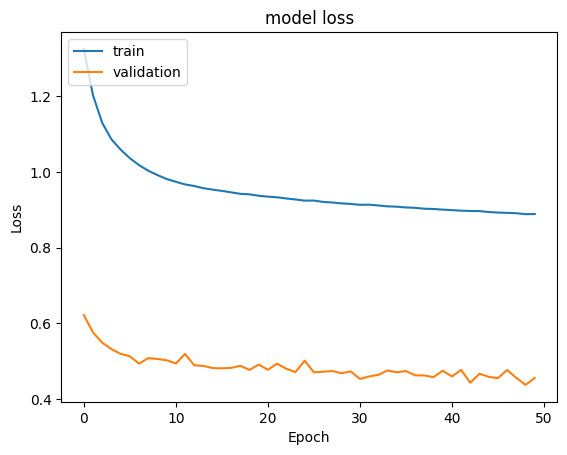

In [276]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_0.history['loss'])
plt.plot(history_0.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Training loss decreases sharply in the first 10 epochs and then gradually levels off. This indicates that the model is learning and improving its performance on the training data. Validation loss dropped slightly at first but then oscialtes with slight dip. The gap between the loss is high.

**Recall**

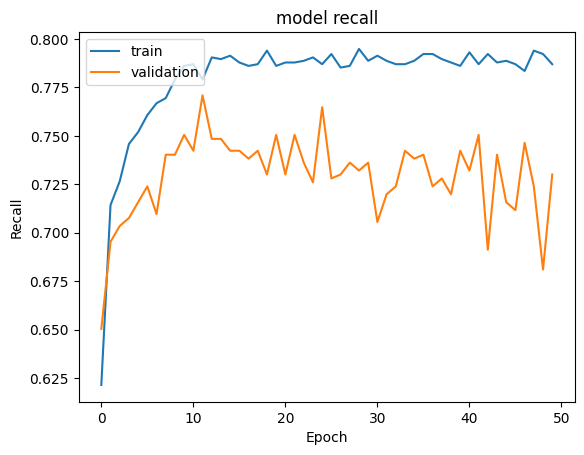

In [277]:
#Plotting Train recall vs Validation recall
plt.plot(history_0.history['recall'])
plt.plot(history_0.history['val_recall'])
plt.title('model recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Validation and train recall starts quickly to rise as the epoch increases but train recall score is stable and validation is volatile at higher epochs.

In [278]:
#Predicting the results using best as a threshold
y_train_pred = model_0.predict(X_train)
y_train_pred

175/175 [==============================] - 1s 3ms/step


array([[0.12435677],
       [0.75812334],
       [0.70178056],
       ...,
       [0.04394468],
       [0.0834192 ],
       [0.66469944]], dtype=float32)

In [279]:
y_train_pred = (y_train_pred > 0.5)
y_train_pred

array([[False],
       [ True],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [280]:
#Predicting the results using best as a threshold
y_val_pred = model_0.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred

75/75 [==============================] - 0s 2ms/step


array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [False],
       [ True]])

In [281]:
model_name = "NN with SGD"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

**Classification report**

In [282]:
#lassification report on training
cr = classification_report(y_train, y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.94      0.81      0.87      4459
           1       0.51      0.78      0.62      1141

    accuracy                           0.80      5600
   macro avg       0.72      0.80      0.74      5600
weighted avg       0.85      0.80      0.82      5600



In [283]:
#classification report on validation
cr=classification_report(y_val, y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.80      0.86      1911
           1       0.49      0.73      0.59       489

    accuracy                           0.79      2400
   macro avg       0.70      0.77      0.72      2400
weighted avg       0.83      0.79      0.80      2400



**Confusion matrix**

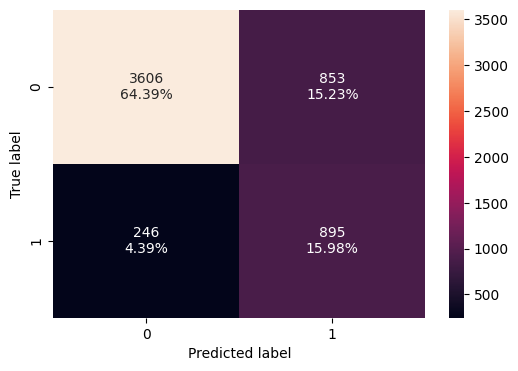

In [284]:
make_confusion_matrix(y_train, y_train_pred)

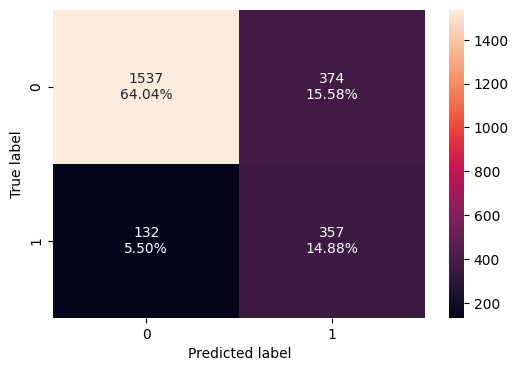

In [285]:
make_confusion_matrix(y_val, y_val_pred)

Recall score of training data 0.78 and validation data is 0.73. It is good score but there is room for improvement.

## Model Performance Improvement

### Neural Network with Adam Optimizer

In [286]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [287]:
#Initializing the neural network
model_1 = Sequential()
#Complete the code to add a input layer (specify the # of neurons and activation function)
model_1.add(Dense(64,activation='relu',input_dim = X_train.shape[1]))
#Complete the code to add a hidden layer (specify the # of neurons and activation function)
model_1.add(Dense(32,activation='relu'))
#Complete the code to add a output layer with the required number of neurons and relu as activation function
model_1.add(Dense(1, activation = 'sigmoid'))

In [288]:
#Complete the code to use Adam as the optimizer.
optimizer = tf.keras.optimizers.Adam()

# uncomment one of the following lines to define the metric to be used
# metric = 'accuracy'
metric = keras.metrics.Recall()
# metric = keras.metrics.Precision()
# metric = keras.metrics.F1Score()

In [289]:
# Complete the code to compile the model with binary cross entropy as loss function and recall as the metric
model_1.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[metric])

In [290]:
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3009 (11.75 KB)
Trainable params: 3009 (11.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [291]:
#Fitting the ANN
history_1 = model_1.fit(
    X_train,y_train,
    batch_size=64,
    validation_data=(X_val,y_val),
    epochs=50,
    verbose=1,
    class_weight=cw_dict
)

Epoch 1/50
88/88 [==============================] - 2s 8ms/step - loss: 1.1679 - recall: 0.6889 - val_loss: 0.5351 - val_recall: 0.7342
Epoch 2/50
88/88 [==============================] - 0s 4ms/step - loss: 1.0090 - recall: 0.7730 - val_loss: 0.5112 - val_recall: 0.7423
Epoch 3/50
88/88 [==============================] - 0s 4ms/step - loss: 0.9648 - recall: 0.7695 - val_loss: 0.4641 - val_recall: 0.6953
Epoch 4/50
88/88 [==============================] - 0s 4ms/step - loss: 0.9435 - recall: 0.7739 - val_loss: 0.4916 - val_recall: 0.7464
Epoch 5/50
88/88 [==============================] - 0s 4ms/step - loss: 0.9295 - recall: 0.7800 - val_loss: 0.4675 - val_recall: 0.7260
Epoch 6/50
88/88 [==============================] - 0s 4ms/step - loss: 0.9194 - recall: 0.7721 - val_loss: 0.4824 - val_recall: 0.7301
Epoch 7/50
88/88 [==============================] - 0s 5ms/step - loss: 0.9113 - recall: 0.7835 - val_loss: 0.4571 - val_recall: 0.7157
Epoch 8/50
88/88 [==============================

**Loss function**

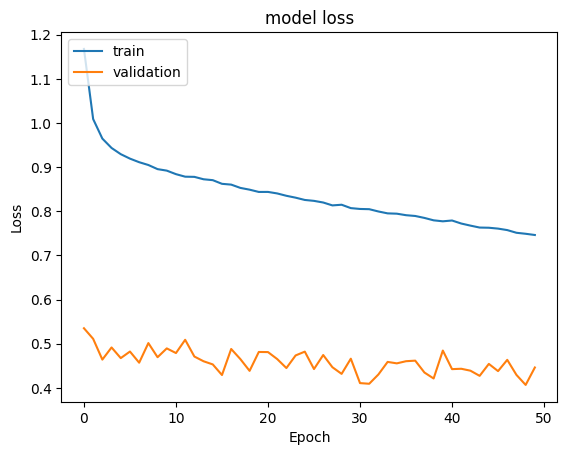

In [292]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Training loss decreases sharply in the first 5 epochs and then gradually levels off but converging. Validation loss dropped slightly at first but then oscialtes within a range.

**Recall**

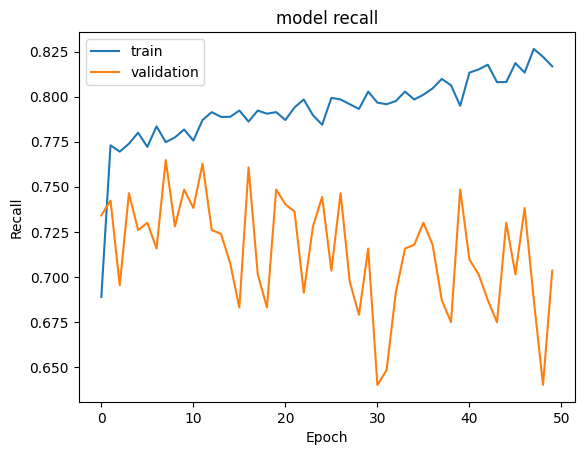

In [293]:
#Plotting Train recall vs Validation recall
plt.plot(history_1.history['recall'])
plt.plot(history_1.history['val_recall'])
plt.title('model recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Validation and train recall starts quickly to rise as the epoch increases. Train recall score is keeps climbing while validation is lot more volatile at higher epochs and recall is decreasing.

In [294]:
#Predicting the results using 0.5 as the threshold
y_train_pred = model_1.predict(X_train)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

175/175 [==============================] - 0s 2ms/step


array([[False],
       [ True],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [295]:
#Predicting the results using 0.5 as the threshold
y_val_pred = model_1.predict(X_val)
y_val_pred

75/75 [==============================] - 0s 2ms/step


array([[0.8439848 ],
       [0.66864634],
       [0.5527351 ],
       ...,
       [0.4725717 ],
       [0.02276989],
       [0.883665  ]], dtype=float32)

In [296]:
y_val_pred = (y_val_pred > 0.5)
y_val_pred

array([[ True],
       [ True],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [297]:
model_name = "NN with Adam"

train_metric_df.loc[model_name] = recall_score(y_train,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [298]:
#lassification report
cr=classification_report(y_train,y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.95      0.83      0.89      4459
           1       0.56      0.83      0.67      1141

    accuracy                           0.83      5600
   macro avg       0.76      0.83      0.78      5600
weighted avg       0.87      0.83      0.84      5600



In [299]:
#classification report
cr=classification_report(y_val,y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1911
           1       0.51      0.70      0.59       489

    accuracy                           0.80      2400
   macro avg       0.71      0.76      0.73      2400
weighted avg       0.83      0.80      0.81      2400



**Confusion matrix**

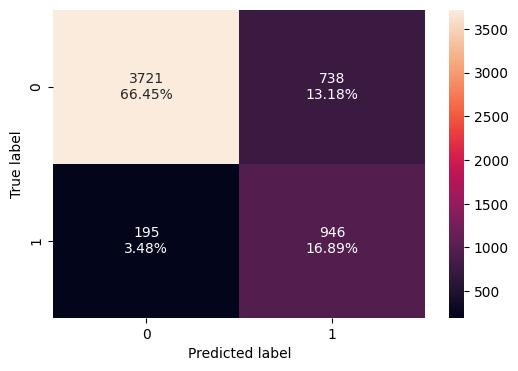

In [300]:
#Calculating the confusion matrix
make_confusion_matrix(y_train, y_train_pred)

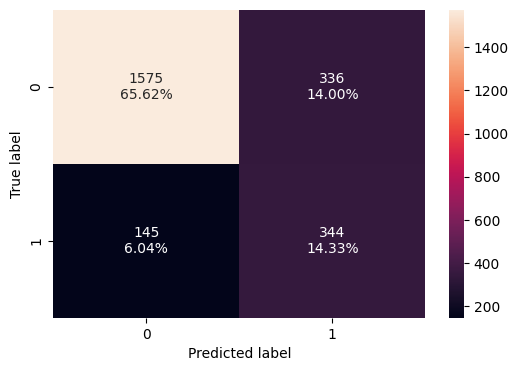

In [301]:
#Calculating the confusion matrix
make_confusion_matrix(y_val,y_val_pred)

Recall score of training data 0.83 and validation data is 0.70. It is good Recall score of training is better than previous model but overall performance slips. In the next iteration we will tweak some parameters to see better performance.

### Neural Network with Adam Optimizer and Dropout

In [302]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [303]:
#Initializing the neural network
model_2 = Sequential()
#Adding the input layer with 32 neurons and relu as activation function
model_2.add(Dense(32,activation='relu',input_dim = X_train.shape[1]))
#Adding dropout
model_2.add(Dropout(0.3))
#Adding the hidden layer with 16 neurons and relu as activation function
model_2.add(Dense(32,activation='relu'))
#Adding dropout
model_2.add(Dropout(0.2))
#Adding the hidden layer with 16 neurons and relu as activation function
model_2.add(Dense(16,activation='relu'))
#Adding the output layer with 1 neurons and sigmoid as activation function
model_2.add(Dense(1, activation = 'sigmoid'))

In [304]:
#Using Adam as the optimizer.
optimizer = tf.keras.optimizers.Adam()

metric = keras.metrics.Recall()


In [305]:
##compile the model with binary cross entropy as loss function and recall as the metric.
model_2.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[metric])

In [306]:
# Summary of the model
model_2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                448       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                1056      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 2049 (8.00 KB)
Trainable params: 2049 (8.0

In [307]:
#Fitting the ANN with batch_size = 32 and 100 epochs
history_2 = model_2.fit(
    X_train,y_train,
    batch_size=64,
    epochs=100,
    verbose=1,
    validation_data=(X_val,y_val),
   class_weight=cw_dict
)

Epoch 1/100
88/88 [==============================] - 2s 8ms/step - loss: 1.3015 - recall: 0.5513 - val_loss: 0.5617 - val_recall: 0.6299
Epoch 2/100
88/88 [==============================] - 0s 5ms/step - loss: 1.1692 - recall: 0.6748 - val_loss: 0.5285 - val_recall: 0.7014
Epoch 3/100
88/88 [==============================] - 0s 5ms/step - loss: 1.1141 - recall: 0.7125 - val_loss: 0.4801 - val_recall: 0.6626
Epoch 4/100
88/88 [==============================] - 0s 5ms/step - loss: 1.0795 - recall: 0.7450 - val_loss: 0.5066 - val_recall: 0.7219
Epoch 5/100
88/88 [==============================] - 0s 5ms/step - loss: 1.0634 - recall: 0.7555 - val_loss: 0.4789 - val_recall: 0.6851
Epoch 6/100
88/88 [==============================] - 1s 8ms/step - loss: 1.0423 - recall: 0.7485 - val_loss: 0.4920 - val_recall: 0.7117
Epoch 7/100
88/88 [==============================] - 1s 8ms/step - loss: 1.0248 - recall: 0.7669 - val_loss: 0.4683 - val_recall: 0.6933
Epoch 8/100
88/88 [======================

**Loss function**

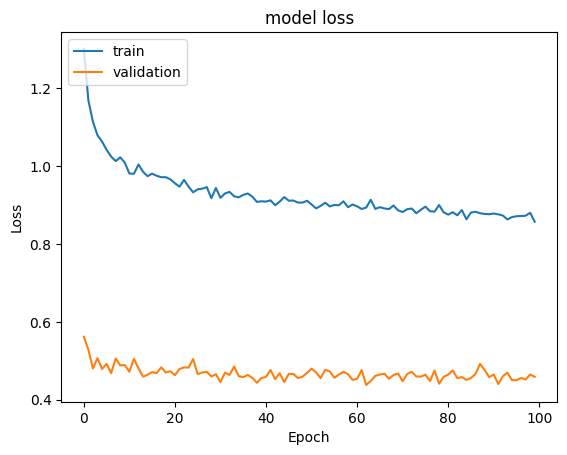

In [308]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

The graph indicates that the model is learning and improving its predictions on the training data, but the consistent gap between the training and validation losses suggests that the model might be underfitting the training data or that there might be some noise in the training data.

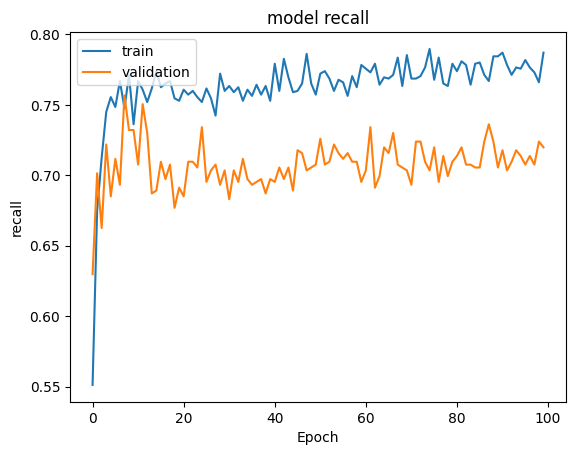

In [309]:
#Plotting Train recall vs Validation recall
plt.plot(history_2.history['recall'])
plt.plot(history_2.history['val_recall'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

There's a noticeable gap between the training and validation recall, especially in the later epochs. This suggests that the model might be overfitting to the training data, meaning it's learning the training set too well and not generalizing well to unseen data.

In [310]:
#Predicting the results using best as a threshold
y_train_pred = model_2.predict(X_train)
y_train_pred = (y_train_pred > 0.5)
y_train_pred

175/175 [==============================] - 0s 2ms/step


array([[False],
       [ True],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [311]:
#Predicting the results using 0.5 as the threshold.
y_val_pred = model_2.predict(X_val)
y_val_pred = (y_val_pred > 0.5)
y_val_pred

75/75 [==============================] - 0s 2ms/step


array([[ True],
       [ True],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [312]:
model_name = "NN with Adam & Dropout"

train_metric_df.loc[model_name] = recall_score(y_train,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [313]:
#classification report
cr=classification_report(y_train,y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.94      0.82      0.88      4459
           1       0.53      0.80      0.64      1141

    accuracy                           0.82      5600
   macro avg       0.74      0.81      0.76      5600
weighted avg       0.86      0.82      0.83      5600



In [314]:
#classification report
cr = classification_report(y_val,y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.80      0.85      1911
           1       0.48      0.72      0.58       489

    accuracy                           0.78      2400
   macro avg       0.70      0.76      0.72      2400
weighted avg       0.83      0.78      0.80      2400



**Confusion matrix**

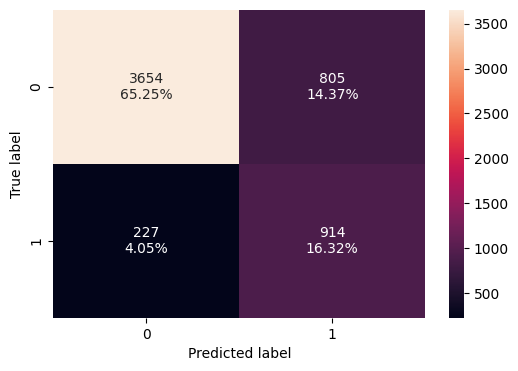

In [315]:
#Calculating the confusion matrix
make_confusion_matrix(y_train, y_train_pred)

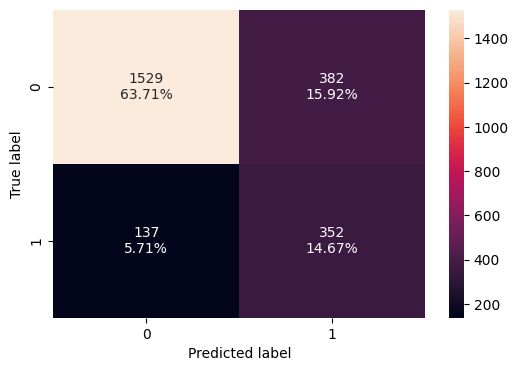

In [316]:
#Calculating the confusion matrix
make_confusion_matrix(y_val,y_val_pred)

Recall score of training data 0.80 and validation data is 0.72. It is good score but there is room for improvement.Better performance than previous model.

### Neural Network with Balanced Data (by applying SMOTE) and SGD Optimizer

**Let's try to apply SMOTE to balance this dataset and then again apply hyperparamter tuning accordingly.**

In [317]:
sm  = SMOTE(random_state=42)
#Complete the code to fit SMOTE on the training data.
X_train_smote, y_train_smote= sm.fit_resample(X_train,y_train)
print('After UpSampling, the shape of train_X: {}'.format(X_train_smote.shape))
print('After UpSampling, the shape of train_y: {} \n'.format(y_train_smote.shape))

After UpSampling, the shape of train_X: (8918, 13)
After UpSampling, the shape of train_y: (8918,) 



In [318]:
y_train_smote.value_counts()

Exited
0    4459
1    4459
Name: count, dtype: int64

Let's build a model with the balanced dataset

In [319]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [320]:
#Initializing the neural network
model_3 = Sequential()
#Adding the input layer with 32 neurons and relu as activation function
model_3.add(Dense(32,activation='relu',input_dim = X_train_smote.shape[1]))
#Adding the hidden layer with 32 neurons and relu as activation function
model_3.add(Dense(16,activation='relu'))
#Adding the hidden layer with 16 neurons and relu as activation function
model_3.add(Dense(16,activation='relu'))
#Adding the output layer with 1 neurons and sigmoid as activation function
model_3.add(Dense(1, activation = 'sigmoid'))


In [321]:
#Using SGD as the optimizer.
optimizer = tf.keras.optimizers.SGD(0.001)

metric = keras.metrics.Recall()


In [322]:
# Compile the model with binary cross entropy as loss function and recall as the metric
model_3.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[metric])

In [323]:
model_3.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                448       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 16)                272       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1265 (4.94 KB)
Trainable params: 1265 (4.94 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [324]:

# simple early stopping
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)

In [325]:
#Fitting the ANN
history_3 = model_3.fit(
    X_train_smote, y_train_smote,
    batch_size=64,
    epochs=100,
    verbose=1,
    validation_data = (X_val,y_val),
    #class_weight=cw_dict,
    #callbacks=[es]
)

Epoch 1/100
140/140 [==============================] - 2s 6ms/step - loss: 0.6910 - recall: 0.2732 - val_loss: 0.6743 - val_recall: 0.2413
Epoch 2/100
140/140 [==============================] - 1s 4ms/step - loss: 0.6897 - recall: 0.3030 - val_loss: 0.6737 - val_recall: 0.2618
Epoch 3/100
140/140 [==============================] - 1s 4ms/step - loss: 0.6885 - recall: 0.3277 - val_loss: 0.6731 - val_recall: 0.2883
Epoch 4/100
140/140 [==============================] - 1s 4ms/step - loss: 0.6872 - recall: 0.3505 - val_loss: 0.6724 - val_recall: 0.3108
Epoch 5/100
140/140 [==============================] - 1s 4ms/step - loss: 0.6860 - recall: 0.3813 - val_loss: 0.6716 - val_recall: 0.3395
Epoch 6/100
140/140 [==============================] - 0s 3ms/step - loss: 0.6847 - recall: 0.4178 - val_loss: 0.6708 - val_recall: 0.3599
Epoch 7/100
140/140 [==============================] - 1s 4ms/step - loss: 0.6835 - recall: 0.4411 - val_loss: 0.6699 - val_recall: 0.3865
Epoch 8/100
140/140 [======

**Loss function**

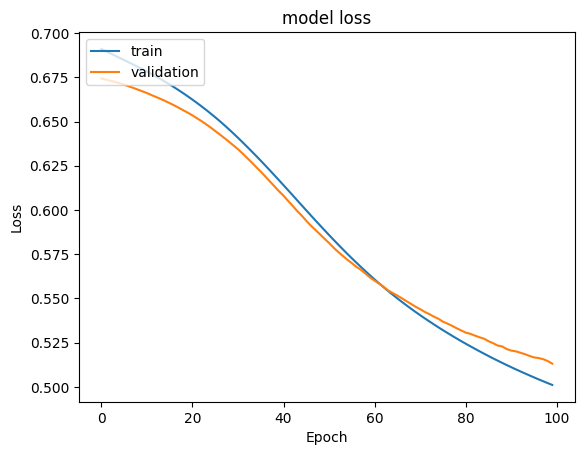

In [326]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Training and validation curve converges around 60 epoch. The graph indicates that the model is learning effectively, with both training and validation loss decreasing steadily. The close tracking of the validation loss with the training loss suggests good generalization to new data.

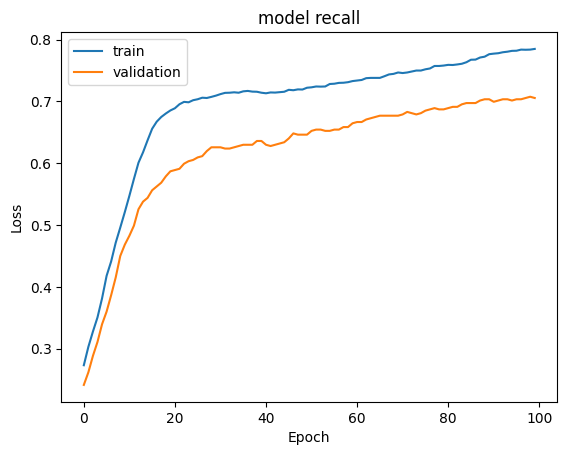

In [327]:
#Plotting Train recall vs Validation recall
plt.plot(history_3.history['recall'])
plt.plot(history_3.history['val_recall'])
plt.title('model recall')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

 The model is learning, but there may be some overfitting since the training recall is significantly higher than the validation recall towards the end of the training period. .

In [328]:
y_train_pred = model_3.predict(X_train_smote)
#Predicting the results using 0.5 as the threshold
y_train_pred = (y_train_pred > 0.5)
y_train_pred

279/279 [==============================] - 1s 2ms/step


array([[False],
       [ True],
       [ True],
       ...,
       [ True],
       [ True],
       [ True]])

In [329]:
y_val_pred = model_3.predict(X_val)
#Predicting the results using 0.5 as the threshold
y_val_pred = (y_val_pred > 0.5)
y_val_pred

75/75 [==============================] - 0s 2ms/step


array([[ True],
       [ True],
       [False],
       ...,
       [ True],
       [False],
       [ True]])

In [330]:
model_name = "NN with SMOTE & SGD"

train_metric_df.loc[model_name] = recall_score(y_train_smote,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [331]:
cr=classification_report(y_train_smote,y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.77      0.74      0.76      4459
           1       0.75      0.78      0.77      4459

    accuracy                           0.76      8918
   macro avg       0.76      0.76      0.76      8918
weighted avg       0.76      0.76      0.76      8918



In [332]:
cr=classification_report(y_val,y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1911
           1       0.43      0.71      0.53       489

    accuracy                           0.75      2400
   macro avg       0.67      0.73      0.68      2400
weighted avg       0.81      0.75      0.77      2400



**Confusion matrix**

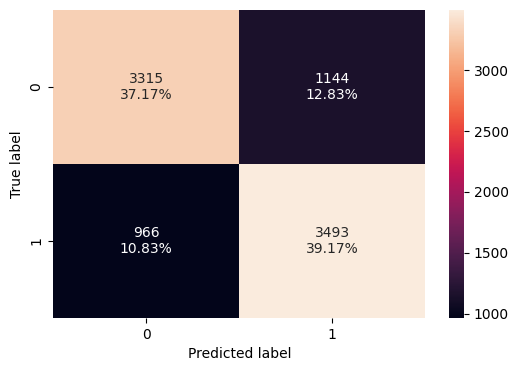

In [333]:
#Calculating the confusion matrix
make_confusion_matrix(y_train_smote, y_train_pred)

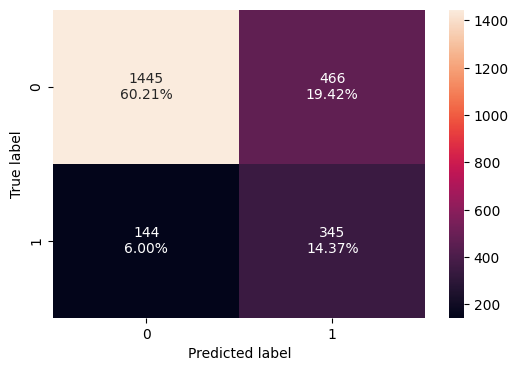

In [334]:
#Calculating the confusion matrix

make_confusion_matrix(y_val,y_val_pred)

Score dropped compared to previous model without SMOTE. Overall performance is poor. The model is signigficantly underperforming in classifying True positive and True negative.

### Neural Network with Balanced Data (by applying SMOTE) and Adam Optimizer

Let's build a model with the balanced dataset

In [335]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [336]:
#Initializing the neural network
model_4 = Sequential()
#Adding the input layer with 32 neurons and relu as activation function
model_4.add(Dense(32,activation='relu',input_dim = X_train_smote.shape[1]))
#Adding the hidden layer with 16 neurons and relu as activation function
model_4.add(Dense(16,activation='relu'))
#Adding the hidden layer with 16 neurons and relu as activation function
model_4.add(Dense(16,activation='relu'))
#Adding the output layer with 1 neurons and sigmoid as activation function
model_4.add(Dense(1, activation = 'sigmoid'))

In [337]:
model_4.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                448       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 16)                272       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1265 (4.94 KB)
Trainable params: 1265 (4.94 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [338]:
#Using Adam as the optimizer.
optimizer = tf.keras.optimizers.Adam(0.00001)

metric = keras.metrics.Recall()


In [339]:
# compile the model with binary cross entropy as loss function and recall as the metric
model_4.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[metric])

In [340]:
#Fitting the ANN

history_4 = model_4.fit(
    X_train_smote,y_train_smote,
    batch_size=64,
    epochs=100,
    verbose=1,
    validation_data = (X_val,y_val),
    #class_weight=cw_dict
)

Epoch 1/100
140/140 [==============================] - 2s 8ms/step - loss: 0.6909 - recall: 0.2660 - val_loss: 0.6735 - val_recall: 0.2311
Epoch 2/100
140/140 [==============================] - 1s 8ms/step - loss: 0.6894 - recall: 0.2839 - val_loss: 0.6723 - val_recall: 0.2434
Epoch 3/100
140/140 [==============================] - 1s 7ms/step - loss: 0.6879 - recall: 0.3050 - val_loss: 0.6710 - val_recall: 0.2577
Epoch 4/100
140/140 [==============================] - 1s 7ms/step - loss: 0.6865 - recall: 0.3270 - val_loss: 0.6697 - val_recall: 0.2761
Epoch 5/100
140/140 [==============================] - 1s 6ms/step - loss: 0.6850 - recall: 0.3481 - val_loss: 0.6684 - val_recall: 0.2904
Epoch 6/100
140/140 [==============================] - 1s 4ms/step - loss: 0.6835 - recall: 0.3781 - val_loss: 0.6672 - val_recall: 0.3170
Epoch 7/100
140/140 [==============================] - 1s 4ms/step - loss: 0.6819 - recall: 0.3985 - val_loss: 0.6658 - val_recall: 0.3415
Epoch 8/100
140/140 [======

**Loss function**

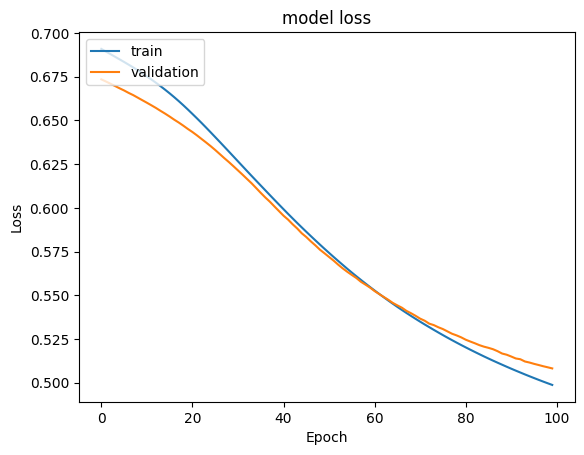

In [341]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Training and validation curve converges around 60 epoch. The graph indicates that the model is learning effectively, with both training and validation loss decreasing steadily. The close tracking of the validation loss with the training loss suggests good generalization to new data.

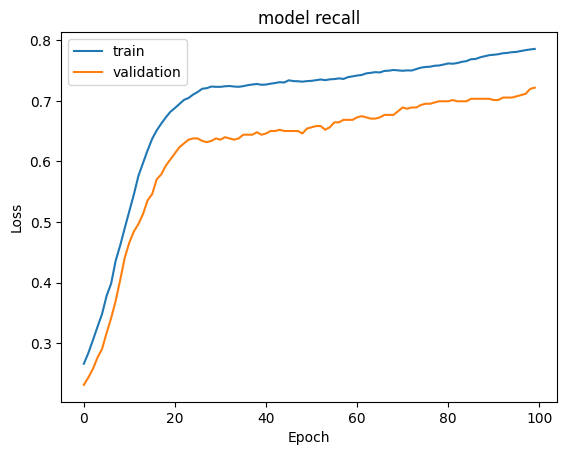

In [342]:
#Plotting Train recall vs Validation recall
plt.plot(history_4.history['recall'])
plt.plot(history_4.history['val_recall'])
plt.title('model recall')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

 The model is learning, but there may be some overfitting since the training recall is significantly higher than the validation recall towards the end of the training period. .

In [343]:
y_train_pred = model_4.predict(X_train_smote)
#Predicting the results using 0.5 as the threshold
y_train_pred = (y_train_pred > 0.5)
y_train_pred

279/279 [==============================] - 1s 2ms/step


array([[False],
       [ True],
       [ True],
       ...,
       [ True],
       [ True],
       [ True]])

In [344]:
y_val_pred = model_4.predict(X_val)
#Predicting the results using 0.5 as the threshold
y_val_pred = (y_val_pred > 0.5)
y_val_pred

75/75 [==============================] - 0s 2ms/step


array([[ True],
       [ True],
       [False],
       ...,
       [False],
       [False],
       [ True]])

In [345]:
model_name = "NN with SMOTE & Adam"

train_metric_df.loc[model_name] = recall_score(y_train_smote,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [346]:
cr=classification_report(y_train_smote,y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.78      0.75      0.76      4459
           1       0.76      0.79      0.77      4459

    accuracy                           0.77      8918
   macro avg       0.77      0.77      0.77      8918
weighted avg       0.77      0.77      0.77      8918



In [347]:
cr=classification_report(y_val,y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1911
           1       0.44      0.72      0.55       489

    accuracy                           0.76      2400
   macro avg       0.68      0.74      0.69      2400
weighted avg       0.82      0.76      0.78      2400



**Confusion matrix**

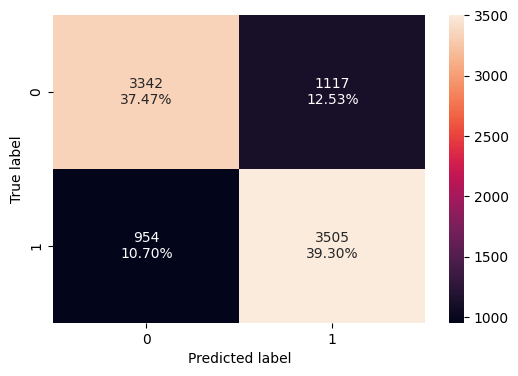

In [348]:
#Calculating the confusion matrix
make_confusion_matrix(y_train_smote, y_train_pred)

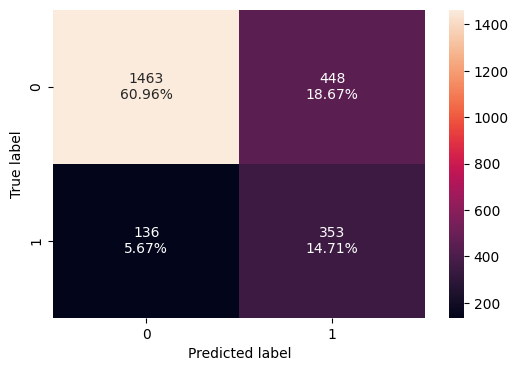

In [349]:
#Calculating the confusion matrix
make_confusion_matrix(y_val,y_val_pred)

No improvement in the model performance. The model still signigficantly underperforming in classifying True positive and True negative.

### Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, and Dropout

In [350]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [351]:
#Initializing the neural network
model_5 = Sequential()
#Adding the input layer with 32 neurons and relu as activation function
model_5.add(Dense(32,activation='relu',input_dim = X_train.shape[1]))
#Adding dropout
model_5.add(Dropout(0.3))
#Adding the hidden layer with 16 neurons and relu as activation function
model_5.add(Dense(16,activation='relu'))
#Adding dropout
model_5.add(Dropout(0.2))
#Adding the hidden layer with 16 neurons and relu as activation function
model_5.add(Dense(8,activation='relu'))
#Adding the output layer with 1 neurons and sigmoid as activation function
model_5.add(Dense(1, activation = 'sigmoid'))

In [352]:
#Using Adam as the optimizer.
optimizer = tf.keras.optimizers.Adam(0.0001)

metric = keras.metrics.Recall()


In [353]:
# compile the model with binary cross entropy as loss function and recall as the metric
model_5.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[metric])

In [354]:
model_5.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                448       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_2 (Dense)             (None, 8)                 136       
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1121 (4.38 KB)
Trainable params: 1121 (4.3

In [355]:
#Fitting the ANN

history_5 = model_5.fit(
    X_train_smote,y_train_smote,
    batch_size=64,
    epochs=75,
    verbose=1,
    validation_data = (X_val,y_val),
    #class_weight=cw_dict
)

Epoch 1/75
140/140 [==============================] - 4s 10ms/step - loss: 0.6897 - recall: 0.7098 - val_loss: 0.6877 - val_recall: 0.7198
Epoch 2/75
140/140 [==============================] - 1s 8ms/step - loss: 0.6794 - recall: 0.6858 - val_loss: 0.6709 - val_recall: 0.6667
Epoch 3/75
140/140 [==============================] - 1s 7ms/step - loss: 0.6714 - recall: 0.6264 - val_loss: 0.6521 - val_recall: 0.6380
Epoch 4/75
140/140 [==============================] - 1s 5ms/step - loss: 0.6572 - recall: 0.6293 - val_loss: 0.6292 - val_recall: 0.6237
Epoch 5/75
140/140 [==============================] - 1s 5ms/step - loss: 0.6453 - recall: 0.6300 - val_loss: 0.6047 - val_recall: 0.6074
Epoch 6/75
140/140 [==============================] - 1s 4ms/step - loss: 0.6299 - recall: 0.6389 - val_loss: 0.5797 - val_recall: 0.6115
Epoch 7/75
140/140 [==============================] - 1s 5ms/step - loss: 0.6144 - recall: 0.6549 - val_loss: 0.5589 - val_recall: 0.6135
Epoch 8/75
140/140 [=============

**Loss function**

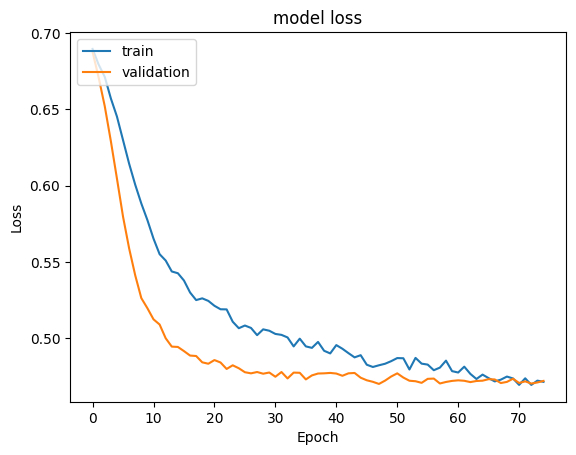

In [356]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

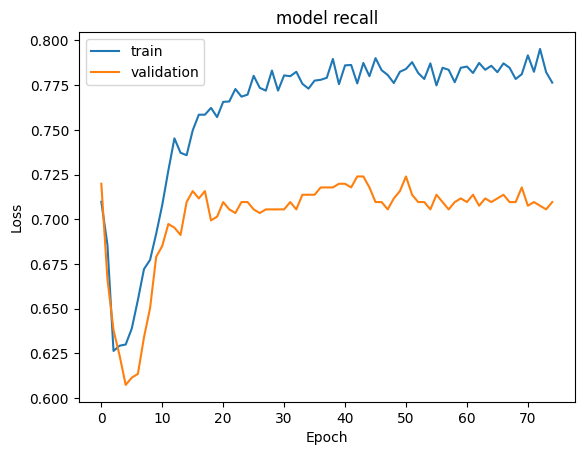

In [357]:
#Plotting Train recall vs Validation recall
plt.plot(history_5.history['recall'])
plt.plot(history_5.history['val_recall'])
plt.title('model recall')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [358]:
y_train_pred = model_5.predict(X_train_smote)
#Predicting the results using 0.5 as the threshold
y_train_pred = (y_train_pred > 0.5)
y_train_pred

279/279 [==============================] - 1s 3ms/step


array([[False],
       [ True],
       [ True],
       ...,
       [ True],
       [ True],
       [ True]])

In [359]:
y_val_pred = model_5.predict(X_val)
#Predicting the results using 0.5 as the threshold
y_val_pred = (y_val_pred > 0.5)
y_val_pred

75/75 [==============================] - 0s 2ms/step


array([[ True],
       [ True],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [360]:
model_name = "NN with SMOTE,Adam & Dropout"

train_metric_df.loc[model_name] = recall_score(y_train_smote,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [361]:
cr=classification_report(y_train_smote,y_train_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      4459
           1       0.79      0.80      0.80      4459

    accuracy                           0.80      8918
   macro avg       0.80      0.80      0.80      8918
weighted avg       0.80      0.80      0.80      8918



In [362]:
#classification report
cr=classification_report(y_val,y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1911
           1       0.47      0.71      0.57       489

    accuracy                           0.78      2400
   macro avg       0.69      0.75      0.71      2400
weighted avg       0.82      0.78      0.79      2400



**Confusion matrix**

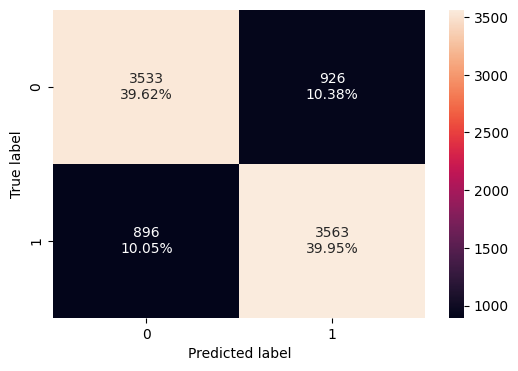

In [363]:
#Calculating the confusion matrix
make_confusion_matrix(y_train_smote, y_train_pred)

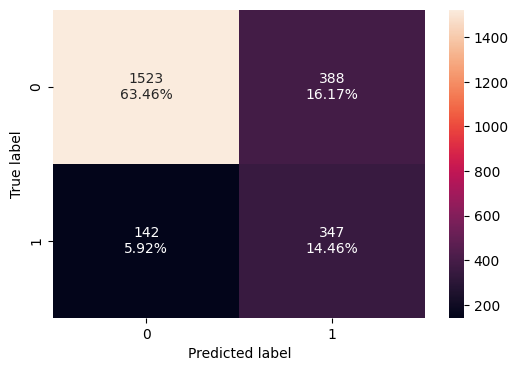

In [364]:
#Calculating the confusion matrix
make_confusion_matrix(y_val,y_val_pred)

No improvement in the model performance.

## Model Performance Comparison and Final Model Selection

In [365]:
recall_score(y_train_smote,y_train_pred)


0.7990580847723705

In [366]:
recall_score(y_val,y_val_pred)

0.7096114519427403

In [367]:
print("Training performance comparison")
train_metric_df

Training performance comparison


,recall
NN with SGD,0.784400
NN with Adam,0.829097
NN with Adam & Dropout,0.801052
NN with SMOTE & SGD,0.783359
NN with SMOTE & Adam,0.786051
"NN with SMOTE,Adam & Dropout",0.799058


In [368]:
print("Validation set performance comparison")
valid_metric_df

Validation set performance comparison


,recall
NN with SGD,0.730061
NN with Adam,0.703476
NN with Adam & Dropout,0.719836
NN with SMOTE & SGD,0.705521
NN with SMOTE & Adam,0.721881
"NN with SMOTE,Adam & Dropout",0.709611


In [369]:
train_metric_df - valid_metric_df

,recall
NN with SGD,0.054338
NN with Adam,0.125621
NN with Adam & Dropout,0.081215
NN with SMOTE & SGD,0.077838
NN with SMOTE & Adam,0.064169
"NN with SMOTE,Adam & Dropout",0.089447


When compared model with class weight balanced, the SMOTE data underpreformed overall. But the recall score was better. Model 2 (NN with Adam & Dropout) gives good recall score and overall performance. I have selected this as my model.

In [370]:
y_test_pred = model_2.predict(X_test)
y_test_pred = (y_test_pred > 0.5)
print(y_test_pred)

63/63 [==============================] - 0s 4ms/step
[[False]
 [False]
 [False]
 ...
 [ True]
 [False]
 [False]]


In [371]:
#lets print classification report
cr=classification_report(y_test,y_test_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.93      0.79      0.85      1593
           1       0.48      0.76      0.59       407

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.84      0.78      0.80      2000



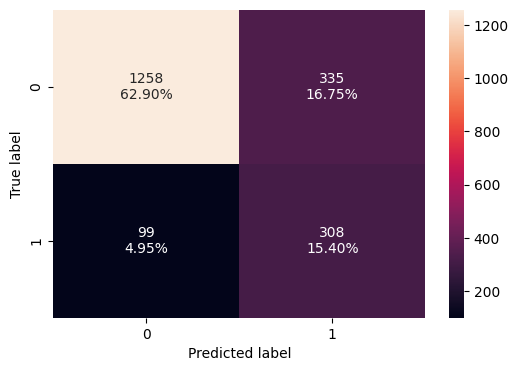

In [372]:
#Calculating the confusion matrix
make_confusion_matrix(y_test,y_test_pred)

## Actionable Insights and Business Recommendations



*   Model gives ~74% of variation in the data correctly.
*   50% of the customers are from France. Bank can diversify customers by attracting customers from other countries.
*   There are only 4 products for customers to work. 97% of customers are having less than 2 products. Customers who have more than 2 are likely to leave.
*   49% of customers are inactive. This could also support the argument of lack of products that were offered.
*   Customers between 45-55 are likely to leave. This needs to be addressed. This pool of customers are above to retire or may be retiring and lack of products to support their plan may have forced to exit.
*   Females are likely to leave. This should also looked into. It could also be due to lack of women centric products.
*Further data like job, education, location and demographic identifiers could help determine multiple models and improve score.

